In [1]:

import os 
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import torch 
import scvi
import gc 
pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)

# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

/home/ubuntu/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/ubuntu/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/ubuntu/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/ubuntu/miniconda3/envs/scvi-tools/l

In [2]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

In [3]:
results_folder = "./results"

In [4]:
# Load spatial data
adata_vis = sc.read_h5ad("./../h5ad/adata_filtered_concat.h5ad")
adata_vis.obs
adata_vis.var

,gene_ids
SAMD11,ENSG00000187634
NOC2L,ENSG00000188976
KLHL17,ENSG00000187961
PLEKHN1,ENSG00000187583
PERM1,ENSG00000187642
...,...
MT-ND4L,ENSG00000212907
MT-ND4,ENSG00000198886
MT-ND5,ENSG00000198786
MT-ND6,ENSG00000198695


In [5]:
# Find mitochondrial genes
adata_vis.var['MT_gene'] = [gene.startswith('MT-') for gene in adata_vis.var.index]

# Remove MT genes for spatial mapping but keep their counts in the object
adata_vis.obsm['MT'] = adata_vis[:, adata_vis.var["MT_gene"].values].X.toarray()
adata_vis = adata_vis[:,~adata_vis.var["MT_gene"].values]

In [6]:
study = ['Banovich_Kropski_2020']

/home/ubuntu/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


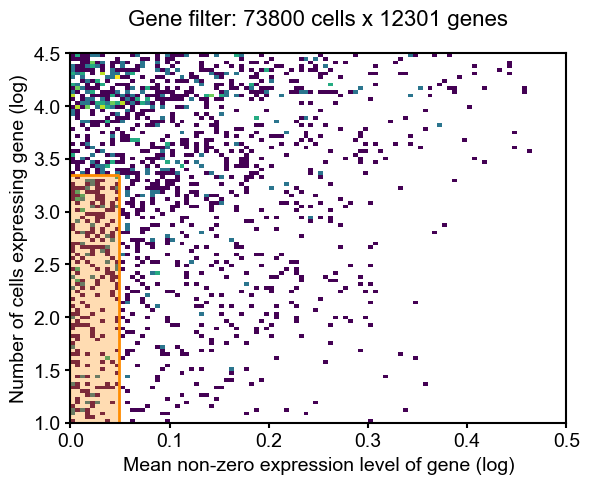

Anndata setup with scvi-tools version 1.2.0.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': 'counts',
│   'batch_key': 'study',
│   'labels_key': 'original_ann_nonharmonized',
│   'categorical_covariate_keys': ['assay'],
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 73800 │
│ n_extra_categorical_covs │   1   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  31   │
│          n_vars          │ 12301 │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │           adata.layers['counts']           │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│         ind_x          │           adata.obs['_indices']            │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

...

                    extra_categorical_covs State Registry                    
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃           Categories           ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['assay'] │ 10x 5' transcription profiling │          0          │
│                    │                                │                     │
└────────────────────┴────────────────────────────────┴─────────────────────┘

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/ubuntu/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/ubuntu/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 250/250: 100%|██████████| 250/250 [11:05<00:00,  2.68s/it, v_num=1, elbo_train=5.2e+8] 

`Trainer.fit` stopped: `max_epochs=250` reached.


Sampling global variables, sample: 100%|██████████| 999/999 [00:07<00:00, 136.75it/s]


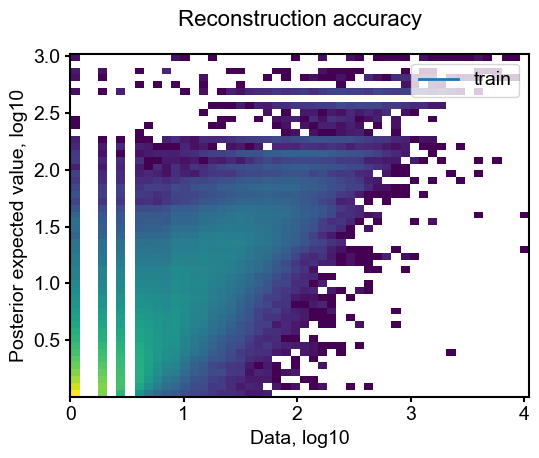

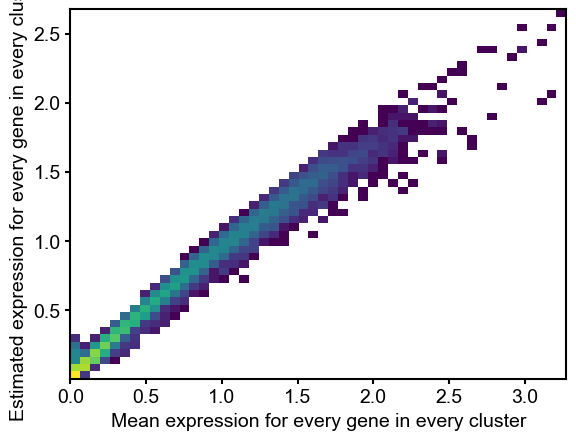

Seed set to 0


./results/cell2location_map_Banovich_Kropski_2020_batch1_seed0


Anndata setup with scvi-tools version 1.2.0.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'library_id',
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

...

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/ubuntu/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/ubuntu/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/ubuntu/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 30000/30000: 100%|██████████| 30000/30000 [1:48:22<00:00,  4.62it/s, v_num=1, elbo_train=4.17e+8]  

`Trainer.fit` stopped: `max_epochs=30000` reached.


Sampling global variables, sample: 100%|██████████| 999/999 [00:17<00:00, 55.56it/s]


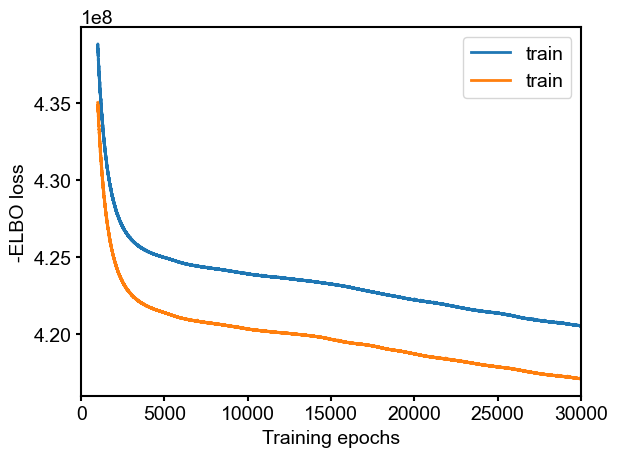

In [7]:
for i, study in enumerate(study):
    # Read adata_ref already subset by study
    adata_ref_disease = sc.read_h5ad(f"./../h5ad/adata_ref_disease_{study}.h5ad")


    # Create paths and names to results folders for reference regression and cell2lcation models
    ref_run_name = f'{results_folder}/reference_signatures_{study}'
    os.makedirs(ref_run_name, exist_ok=True)

    # Convert NaN into Unknown
    if pd.isna(adata_ref_disease.obs['original_ann_nonharmonized']).any() == True:
        adata_ref_disease.obs['original_ann_nonharmonized'] = adata_ref_disease.obs['original_ann_nonharmonized'].fillna("Unknown")

    # Change ENSEMBL names to Symbols
    adata_ref_disease.var["ens"] = adata_ref_disease.var.index
    adata_ref_disease.var.index = adata_ref_disease.var["original_gene_symbols"]

    # Save raw counts
    adata_ref_disease.layers["counts"] = adata_ref_disease.raw.X.copy()

    # Permissive filtering
    from cell2location.utils.filtering import filter_genes
    selected = filter_genes(adata_ref_disease, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

    # filter the object
    adata_ref_disease = adata_ref_disease[:, selected].copy()

    # prepare anndata for the regression model
    cell2location.models.RegressionModel.setup_anndata(adata=adata_ref_disease,
                            layer = "counts",
                            # 10X reaction / sample / batch
                            batch_key='study',
                            # cell type, covariate used for constructing signatures
                            labels_key='original_ann_nonharmonized',
                            # multiplicative technical effects (platform, 3' vs 5', donor effect)
                            categorical_covariate_keys=['assay']
                        )
    
    # create the regression model
    from cell2location.models import RegressionModel
    mod = RegressionModel(adata_ref_disease)

    # view anndata_setup as a sanity check
    mod.view_anndata_setup()

    mod.train(max_epochs=250)

    mod.plot_history(20)
    # Save plots
    plt.savefig(os.path.join(ref_run_name, "train_elbo.png"), transparent=True, bbox_inches='tight')
    plt.savefig(os.path.join(ref_run_name, "train_elbo.svg"), transparent=True, bbox_inches='tight')
    plt.savefig(os.path.join(ref_run_name, "train_elbo.pdf"), transparent=True, bbox_inches='tight')    


    # In this section, we export the estimated cell abundance (summary of the posterior distribution).
    adata_ref_disease = mod.export_posterior(
        adata_ref_disease, sample_kwargs={'num_samples': 1000, 'batch_size': 2500}
    )

    mod.plot_QC()
    # Save plots
    plt.savefig(os.path.join(ref_run_name, "qc.png"), transparent=True, bbox_inches='tight')
    plt.savefig(os.path.join(ref_run_name, "qc.svg"), transparent=True, bbox_inches='tight')
    plt.savefig(os.path.join(ref_run_name, "qc.pdf"), transparent=True, bbox_inches='tight')  



    # Save model
    mod.save(f"{ref_run_name}", overwrite=True)
    # Save anndata object with results
    adata_file = f"{ref_run_name}/sc.h5ad"
    adata_ref_disease.var.index.name = None
    adata_ref_disease.write(adata_file)

    # Point to paths and names to results folders for reference regression and cell2lcation models
    # ref_run_name = f'{results_folder}/reference_signatures_{study}'
    run_name = f'{results_folder}/cell2location_map_{study}'

    # load sc model
    # adata_file = f"{ref_run_name}/sc.h5ad"
    # adata_ref_disease = sc.read_h5ad(adata_file)
    # mod = cell2location.models.RegressionModel.load(f"{ref_run_name}", adata_ref_disease)

    # adata_ref_disease = mod.export_posterior(adata_ref_disease, sample_kwargs={'num_samples': 1000, 'batch_size': 2500})
    
    # export estimated expression in each cluster
    # this is the estimated expression of every gene in every cell type
    if 'means_per_cluster_mu_fg' in adata_ref_disease.varm.keys():
        inf_aver = adata_ref_disease.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                        for i in adata_ref_disease.uns['mod']['factor_names']]].copy()
    else:
        inf_aver = adata_ref_disease.var[[f'means_per_cluster_mu_fg_{i}'
                                        for i in adata_ref_disease.uns['mod']['factor_names']]].copy()
    inf_aver.columns = adata_ref_disease.uns['mod']['factor_names']
    inf_aver.iloc[0:5, 0:5]

    # find shared genes and subset both anndata and reference signatures
    intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)
    adata_vis = adata_vis[:, intersect].copy()
    inf_aver = inf_aver.loc[intersect, :].copy()

    # for every "sample", sample with replacement from chunks to allocate 
    # some locations from each batch to all training batches
    chunk_size = 100000
    chunks = [i for i in range(int(np.ceil(adata_vis.n_obs / chunk_size)))]

    adata_vis.obs['training_batch'] = 0
    for library_id in adata_vis.obs['library_id'].unique():
        ind = adata_vis.obs['library_id'].isin([library_id])
        adata_vis.obs.loc[ind, 'training_batch'] = np.random.choice(
            chunks, size=ind.sum(), replace=True, p=None
        )
        
    adata_vis_full = adata_vis.copy()
    for k in ['means', 'stds', 'q05', 'q95']:
        adata_vis_full.obsm[f"{k}_cell_abundance_w_sf"] = np.zeros((adata_vis_full.n_obs, inf_aver.shape[1]))
        
    adata_vis.obs['training_batch'].value_counts()

    seed = 0
    scvi.settings.seed = seed
    np.random.seed(seed)

    # submit this chunk as separate jobs
    for batch in adata_vis.obs['training_batch'].unique():
        # create and train the model
        scvi_run_name = f'{run_name}_batch{batch}_seed{seed}'
        print(scvi_run_name)

        training_batch_index = adata_vis_full.obs['training_batch'].isin([batch])
        adata_vis = adata_vis_full[training_batch_index, :].copy()
        
        # prepare anndata for scVI model
        cell2location.models.Cell2location.setup_anndata(
            adata=adata_vis, batch_key="library_id"
        )

        # train as normal
        # create and train the model
        mod= cell2location.models.Cell2location(
            adata_vis, cell_state_df=inf_aver,
        # the expected average cell abundance: tissue-dependent
        # hyper-prior which can be estimated from paired histology:
            N_cells_per_location=8,
        # hyperparameter controlling normalisation of
        # within-experiment variation in RNA detection:
            detection_alpha=20
        )
        mod.view_anndata_setup()

        mod.train(max_epochs=30000,
            # train using full data (batch_size=None)
            batch_size=None,
            # use all data points in training because
            # we need to estimate cell abundance at all locations
            train_size=1,
            )

        # plot ELBO loss history during training, removing first 1000 epochs from the plot
        mod.plot_history(1000)

        # Save model
        mod.save(f"{run_name}_{batch}", overwrite=True)
    
        # export posterior
        # In this section, we export the estimated cell abundance (summary of the posterior distribution).
        adata_vis = mod.export_posterior(
            adata_vis, sample_kwargs={
                'batch_size': int(np.ceil(adata_vis.n_obs / 4)), 'accelerator': 'gpu'#,
                #"return_observed": False,
            }#,
            # add_to_obsm=['q05', 'q50'],
            #use_quantiles=True,
        )

        # copy cell2location results to the main object
        for k in adata_vis_full.obsm.keys():
            adata_vis_full.obsm[k][training_batch_index, :] = adata_vis.obsm[k].copy()
        adata_vis_full.uns[f'mod_{batch}'] = adata_vis.uns['mod'].copy()  


    # Save anndata object with results
    adata_file = f"{run_name}/sp.h5ad"

    if not os.path.exists(run_name):
        os.makedirs(run_name)
        
    adata_vis_full.write(adata_file)



    # Clear GPU memory 
    del mod
    gc.collect()
    torch.cuda.empty_cache()
    with torch.no_grad():
        torch.cuda.empty_cache()

    


